In [2]:
# ============================================================
# CELL 1 — SETUP
# Single seed source -> everything downstream is reproducible
# (Trust Card §12: record this seed + package versions).
# ============================================================
import numpy as np, pandas as pd, glob, sys
import sklearn, lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (log_loss, brier_score_loss, roc_auc_score)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

for m in (np, pd, sklearn, lgb):
    print(f"{m.__name__}: {m.__version__}")

tr_path = glob.glob("../csvs/train.csv",  recursive=True)[0]
te_path = glob.glob("../csvs/test.csv",   recursive=True)[0]
ss_path = glob.glob("../csvs/sample_submission.csv", recursive=True)[0]
train, test, ss = (pd.read_csv(p) for p in (tr_path, te_path, ss_path))

ID, TARGET = "patient_id", "readmitted_30d"
y = train[TARGET].values.astype(int)
print("train", train.shape, "| test", test.shape,
      "| prevalence", round(y.mean(), 6))

numpy: 2.1.3
pandas: 2.2.3
sklearn: 1.9.0
lightgbm: 4.7.0
train (7000, 25) | test (3000, 24) | prevalence 0.125857


In [3]:
# ============================================================
# CELL 2 — FEATURES + FROZEN LR BASELINE
# Engineering rules:
#  - deterministic, fit-free transforms -> identical function on train/test
#    CANNOT leak;
#  - sums (n_chronic) and interactions (prior_x_comorb) are expensive for
#    axis-aligned trees -> hand them over explicitly;
#  - threshold flags: interpretability + they give LR its nonlinearity.
#    For LGBM they may be redundant (trees find thresholds alone) — that's
#    fine, we verify via importance in Cell 9 and say so in the Trust Card.
#  - flags treat missing as "not abnormal"; the _wasna flag carries
#    missingness separately, so no information is silently destroyed.
# ============================================================
def engineer(d):
    d = d.copy()
    d["n_chronic"] = d[["diabetes", "hypertension",
                        "chronic_kidney_disease", "heart_failure"]].sum(axis=1)
    d["prior_x_comorb"] = d["prior_admissions_12m"] * d["comorbidity_count"]
    d["abn_creatinine"] = (d["creatinine_mg_dl"]  > 1.2 ).astype(int)
    d["abn_sodium"]     = (d["sodium_mmol_l"]     < 135 ).astype(int)
    d["abn_hemoglobin"] = (d["hemoglobin_g_dl"]   < 12  ).astype(int)
    d["abn_sysbp"]      = ((d["systolic_bp_mmhg"] >= 140) |
                           (d["systolic_bp_mmhg"] < 100)).astype(int)
    d["abn_heartrate"]  = (d["heart_rate_bpm"]    > 100 ).astype(int)
    d["n_abnormal_labs"] = d[["abn_creatinine", "abn_sodium", "abn_hemoglobin",
                              "abn_sysbp", "abn_heartrate"]].sum(axis=1)
    return d

tr_e, te_e = engineer(train), engineer(test)

CATS = ["sex", "rurality", "hospital_type", "region",
        "discharge_disposition", "care_pathway"]
NUMS = [c for c in tr_e.columns if c not in CATS + [ID, TARGET]]

# missingness indicators: test is ~1.4x more missing (Step 1 audit) ->
# "was this lab measured?" is itself signal. Distribution may shift ->
# we keep them but flag as ablation candidates if CV↔LB diverges.
NA_COLS = [c for c in NUMS if tr_e[c].isna().any()]
for d in (tr_e, te_e):
    for c in NA_COLS:
        d[c + "_wasna"] = d[c].isna().astype(int)
NUMS = [c for c in tr_e.columns if c not in CATS + [ID, TARGET]]

X_raw, Xte_raw = tr_e[NUMS + CATS], te_e[NUMS + CATS]
print(f"{len(NUMS)} numeric + {len(CATS)} categorical | NA-flagged: {NA_COLS}")

# ---- LR baseline: ONE-TIME C grid -> frozen spec ----
# WHY a grid now: C=1.0 shrinkage biased our earlier ORs toward 1; C=10 was
# chosen ad hoc. We pick once by CV, freeze, and use THE SAME spec for
# predictions AND odds ratios -> one consistent number in the Trust Card.
# (Mild optimism from selecting on CV among 3 close values — second-order,
# documented, and never re-tuned again.)
pre_lr = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), NUMS),          # LR needs scaling to converge
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATS)])  # drop=first -> identifiable ORs
skf_lr = StratifiedKFold(5, shuffle=True, random_state=SEED)
grid, p_lr_grid = {}, {}
for C in [0.1, 1.0, 10.0]:
    p = cross_val_predict(Pipeline([("pre", pre_lr),
                                    ("clf", LogisticRegression(max_iter=3000, C=C))]),
                          X_raw, y, cv=skf_lr, method="predict_proba")[:, 1]
    grid[C] = log_loss(y, p); p_lr_grid[C] = p
    print(f"LR C={C}: OOF logloss {grid[C]:.5f}")
BEST_C = min(grid, key=grid.get)
p_lr = p_lr_grid[BEST_C]
print(f"\nFROZEN LR spec: C={BEST_C} | OOF logloss {log_loss(y, p_lr):.5f} "
      f"| brier {brier_score_loss(y, p_lr):.5f} | auc {roc_auc_score(y, p_lr):.5f}")

31 numeric + 6 categorical | NA-flagged: ['followup_days', 'hemoglobin_g_dl', 'creatinine_mg_dl', 'sodium_mmol_l', 'heart_rate_bpm', 'systolic_bp_mmhg']
LR C=0.1: OOF logloss 0.35203
LR C=1.0: OOF logloss 0.35237
LR C=10.0: OOF logloss 0.35242

FROZEN LR spec: C=0.1 | OOF logloss 0.35203 | brier 0.10304 | auc 0.68606


In [4]:
# ============================================================
# CELL 3 — LGBM PARAMS (conservative: 7k rows / ~880 positives ->
#          the danger is overfitting, not underfitting)
# ============================================================
LGBM_PARAMS = dict(
    objective="binary",      # log-loss objective = the competition metric itself
    learning_rate=0.05,      # small steps + early stopping -> smoother generalization
    num_leaves=31,           # moderate capacity; deeper trees memorize noise at this n
    min_data_in_leaf=40,     # a leaf needs ~0.6% of data -> real evidence per leaf,
                             # critical with 12.6% prevalence
    feature_fraction=0.85,   # 85% of features per tree -> decorrelates trees
    bagging_fraction=0.85,   # 85% of rows per tree    -> row-axis regularization
    bagging_freq=1,          # required >=1 for bagging to be active
    lambda_l2=1.0,           # shrinks extreme leaf values -> protects log loss
    verbosity=-1, seed=SEED,
)
print("params:", LGBM_PARAMS)

params: {'objective': 'binary', 'learning_rate': 0.05, 'num_leaves': 31, 'min_data_in_leaf': 40, 'feature_fraction': 0.85, 'bagging_fraction': 0.85, 'bagging_freq': 1, 'lambda_l2': 1.0, 'verbosity': -1, 'seed': 42}


In [5]:
# ============================================================
# CELL 4 — REPEATED STRATIFIED CV (3 x 5), leakage-free, FIX APPLIED
# WHY stratified: 12.6% prevalence -> unstratified folds can go event-starved.
# WHY repeated: one split = one number; 3 repeats = a variance estimate
#   (the challenge explicitly demands repeated-CV evidence).
# WHY inner early-stop split: early-stopping on the fold we SCORE would tune
#   the round count on the answer key -> optimistic OOF. Inner 80/20 keeps
#   the scored fold untouched.
# WHY pass 2 refits on ALL of tr_i (FIX): pass 1 trains on 80% of fold-train
#   just to find best_iteration; reusing that 80% model for scoring wasted
#   20% of fold-train and made OOF pessimistic AND mismatched to deployment
#   (final model trains on 100%). Now: preprocessing AND booster refit on
#   full tr_i, frozen round count. Honest + matched.
# WHY a reusable function: Cell 10's ablation must use the IDENTICAL
#   protocol/folds, or the with/without comparison is confounded.
# ============================================================
def make_pre(nums, cats):
    # median: robust to skewed labs | one-hot ignore-unknown: safe at predict time
    # (no scaling: trees are scale-invariant -> one less step that could leak)
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), nums),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cats)])

def run_repeated_cv(nums, cats, R=3, K=5, tag="LGBM"):
    oof = np.zeros((R, len(y)))
    iters = []
    for r in range(R):
        cv = StratifiedKFold(K, shuffle=True, random_state=SEED + 100 + r)
        for k, (tr_i, va_i) in enumerate(cv.split(X_raw, y)):
            # --- pass 1: inner split, find best_iteration ---
            fit_i, es_i = train_test_split(tr_i, test_size=0.2,
                                           stratify=y[tr_i],
                                           random_state=SEED + r * 10 + k)
            pre_es = make_pre(nums, cats)
            Xfit = pre_es.fit_transform(X_raw.iloc[fit_i]).astype(np.float32)
            Xes  = pre_es.transform(X_raw.iloc[es_i]).astype(np.float32)
            m = lgb.train(LGBM_PARAMS, lgb.Dataset(Xfit, y[fit_i]),
                          num_boost_round=2000,
                          valid_sets=[lgb.Dataset(Xes, y[es_i])],
                          callbacks=[lgb.early_stopping(100, verbose=False)])
            iters.append(m.best_iteration)
            # --- pass 2 (FIXED): refit on ALL fold-train, frozen rounds ---
            pre = make_pre(nums, cats)
            Xtr = pre.fit_transform(X_raw.iloc[tr_i]).astype(np.float32)
            Xva = pre.transform(X_raw.iloc[va_i]).astype(np.float32)
            m2 = lgb.train(LGBM_PARAMS, lgb.Dataset(Xtr, y[tr_i]),
                           num_boost_round=m.best_iteration)
            oof[r, va_i] = m2.predict(Xva)
        print(f"  {tag} repeat {r+1}: logloss {log_loss(y, oof[r]):.5f}")
    return oof, iters

oof_lgbm, best_iters = run_repeated_cv(NUMS, CATS)
p_lgbm = oof_lgbm.mean(0)          # averaged OOF: lower variance, still honest
lls = [log_loss(y, oof_lgbm[r]) for r in range(oof_lgbm.shape[0])]
print(f"\nLGBM log loss: {np.mean(lls):.5f} ± {np.std(lls):.5f} (across repeats)")
print(f"pooled: brier {brier_score_loss(y, p_lgbm):.5f} | auc {roc_auc_score(y, p_lgbm):.5f}")
print(f"median best_iteration: {int(np.median(best_iters))}")
np.save("p_oof_lgbm.npy", p_lgbm)

  LGBM repeat 1: logloss 0.35644
  LGBM repeat 2: logloss 0.35489
  LGBM repeat 3: logloss 0.35542

LGBM log loss: 0.35559 ± 0.00065 (across repeats)
pooled: brier 0.10359 | auc 0.68094
median best_iteration: 41


In [6]:
# ============================================================
# CELL 5 — PAIRED BOOTSTRAP
# WHY paired: resampling the SAME patients for both models cancels shared
# sampling noise -> the CI on the DIFFERENCE is far tighter than comparing
# two independent CIs. Sign: CI of LL(a) - LL(b); positive = a is worse.
# ============================================================
p_const = np.full(len(y), y.mean())
rng = np.random.default_rng(SEED)

def paired_bootstrap(p_a, p_b, B=2000):
    d = np.empty(B)
    for b in range(B):
        i = rng.integers(0, len(y), len(y))
        d[b] = log_loss(y[i], p_a[i]) - log_loss(y[i], p_b[i])
    return np.percentile(d, [2.5, 97.5])

ci_lr  = paired_bootstrap(p_lgbm, p_lr)     # positive => LGBM worse than LR
ci_cst = paired_bootstrap(p_lgbm, p_const)
print(f"LGBM vs LR:      CI [{ci_lr[0]:+.5f}, {ci_lr[1]:+.5f}] "
      f"-> {'LGBM WORSE' if ci_lr[0] > 0 else 'LGBM BETTER' if ci_lr[1] < 0 else 'NOT significant'}")
print(f"LGBM vs const:   CI [{ci_cst[0]:+.5f}, {ci_cst[1]:+.5f}] "
      f"-> {'SIGNIFICANT improvement' if ci_cst[1] < 0 else 'not significant'}")

bs = [log_loss(y[i], p_lgbm[i]) for i in
      (rng.integers(0, len(y), len(y)) for _ in range(2000))]
print(f"LGBM log loss 95% CI: [{np.percentile(bs,2.5):.5f}, {np.percentile(bs,97.5):.5f}]")

LGBM vs LR:      CI [-0.00167, +0.00443] -> NOT significant
LGBM vs const:   CI [-0.03015, -0.01986] -> SIGNIFICANT improvement
LGBM log loss 95% CI: [0.33877, 0.36827]


uncalibrated OOF log loss: 0.35348
nested-calibrated [platt   ]: 0.35342
nested-calibrated [isotonic]: 0.35590
calibration slope 1.081 | intercept 0.176 (ideal 1.0 / 0.0)


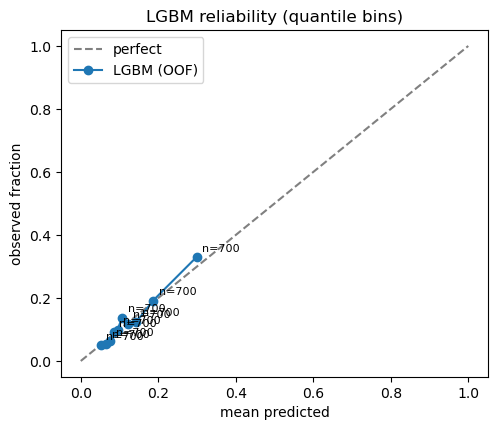

chosen calibration: platt | gain: +0.00007


In [7]:
# ============================================================
# CELL 6 — CALIBRATION BEFORE vs AFTER
# WHY: LGBM optimizes splits, not probability fidelity -> unlike LR it is
#   NOT natively calibrated. Slope<1 = overconfident (the expected LGBM
#   failure); slope>1 = underconfident. Ideal: slope 1.0, intercept 0.0.
# WHY nested: calibrator evaluated on data it never fit -> honest gain.
# WHY both methods: isotonic is flexible but data-hungry (~880 positives is
#   borderline); Platt has 1 parameter and is very stable. Nested CV picks.
# WHY quantile bins: with 12.6% prevalence, uniform bins above p~0.4 hold a
#   handful of patients -> the garbage spikes we saw in the earlier LR plot.
# ============================================================
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def nested_calibrate(p, method, K=5):
    out = np.zeros(len(y))
    for tr_i, te_i in StratifiedKFold(K, shuffle=True,
                                      random_state=SEED).split(p, y):
        if method == "isotonic":
            c = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1-1e-4)
            c.fit(p[tr_i], y[tr_i]); out[te_i] = c.predict(p[te_i])
        else:
            c = LogisticRegression(C=1e6, max_iter=1000)
            c.fit(logit(p[tr_i]).reshape(-1, 1), y[tr_i])
            out[te_i] = c.predict_proba(logit(p[te_i]).reshape(-1, 1))[:, 1]
    return out

print(f"uncalibrated OOF log loss: {log_loss(y, p_lgbm):.5f}")
cal_scores = {}
for meth in ["platt", "isotonic"]:
    cal_scores[meth] = log_loss(y, nested_calibrate(p_lgbm, meth))
    print(f"nested-calibrated [{meth:8s}]: {cal_scores[meth]:.5f}")

sl = LogisticRegression(C=1e6).fit(logit(p_lgbm).reshape(-1, 1), y)
print(f"calibration slope {sl.coef_[0][0]:.3f} | intercept {sl.intercept_[0]:.3f} "
      f"(ideal 1.0 / 0.0)")

pt, pp = calibration_curve(y, p_lgbm, n_bins=10, strategy="quantile")
qs = np.quantile(p_lgbm, np.linspace(0, 1, 11))
counts = np.histogram(p_lgbm, bins=qs)[0]
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot([0, 1], [0, 1], "--", c="gray", label="perfect")
ax.plot(pp, pt, "o-", label="LGBM (OOF)")
for x_, t_, n_ in zip(pp, pt, counts):
    ax.annotate(f"n={n_}", (x_, t_), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("mean predicted"); ax.set_ylabel("observed fraction")
ax.set_title("LGBM reliability (quantile bins)"); ax.legend(); plt.show()

BEST_CAL = min(cal_scores, key=cal_scores.get)
print("chosen calibration:", BEST_CAL,
      "| gain:", f"{log_loss(y, p_lgbm) - cal_scores[BEST_CAL]:+.5f}")

In [8]:
# ============================================================
# CELL 7 — SUBGROUP RELIABILITY (real model now)
# WHY skill-vs-floor: log loss has a prevalence-dependent floor even for a
#   perfect model -> raw per-group log loss exaggerates "problems" in
#   high-risk groups. Skill = value added over the group's OWN constant.
# WHY CI: a negative skill in a tiny group may be noise; the CI tells us.
# (Differences are associational, not causal — say this in the Trust Card.)
# ============================================================
def skill_ci(p, yy, B=500):
    r = np.random.default_rng(SEED); s = []
    for _ in range(B):
        i = r.integers(0, len(yy), len(yy))
        s.append(log_loss(yy[i], np.full(len(i), yy[i].mean())) - log_loss(yy[i], p[i]))
    return np.percentile(s, [2.5, 97.5])

age_g = pd.cut(tr_e.age, [0, 30, 50, 70, 200],
               labels=["<30", "30-50", "50-70", "70+"])
for col, series in [("rurality", tr_e.rurality), ("region", tr_e.region),
                    ("sex", tr_e.sex), ("hospital_type", tr_e.hospital_type),
                    ("age_group", age_g)]:
    print(f"\n[{col}]")
    for g in series.unique():
        idx = np.where((series == g).values)[0]
        sk = log_loss(y[idx], np.full(len(idx), y[idx].mean())) - log_loss(y[idx], p_lgbm[idx])
        lo, hi = skill_ci(p_lgbm[idx], y[idx]) if len(idx) >= 50 else (np.nan, np.nan)
        flag = "  <-- model HURTS here (CI excludes 0)" if hi < 0 else ""
        print(f"  {str(g):12s} n={len(idx):4d}  base={y[idx].mean():.3f}  "
              f"skill={sk:+.4f}  CI[{lo:+.4f},{hi:+.4f}]{flag}")


[rurality]
  Rural        n=1243  base=0.156  skill=+0.0301  CI[+0.0171,+0.0425]
  Urban        n=3887  base=0.124  skill=+0.0221  CI[+0.0155,+0.0284]
  Semi-urban   n=1870  base=0.109  skill=+0.0235  CI[+0.0142,+0.0325]

[region]
  Central      n=1529  base=0.129  skill=+0.0333  CI[+0.0215,+0.0446]
  North-East   n=1326  base=0.115  skill=+0.0286  CI[+0.0159,+0.0399]
  West         n=2591  base=0.125  skill=+0.0171  CI[+0.0099,+0.0253]
  South        n=1554  base=0.134  skill=+0.0258  CI[+0.0154,+0.0370]

[sex]
  Female       n=3543  base=0.124  skill=+0.0249  CI[+0.0175,+0.0312]
  Male         n=3457  base=0.128  skill=+0.0249  CI[+0.0171,+0.0320]

[hospital_type]
  General      n=2623  base=0.122  skill=+0.0256  CI[+0.0173,+0.0341]
  Teaching     n=3092  base=0.130  skill=+0.0219  CI[+0.0144,+0.0298]
  District     n=1285  base=0.124  skill=+0.0306  CI[+0.0178,+0.0427]

[age_group]
  30-50        n=2030  base=0.078  skill=+0.0047  CI[+0.0004,+0.0088]
  <30          n= 343  base=0.0

In [9]:
# ============================================================
# CELL 8 — UNCERTAINTY REFERRAL + ROBUSTNESS
# 8a WHY the random-referral control: log loss is maximized at p=0.5, so
#   deleting high-entropy rows helps MECHANICALLY. The claim "the model
#   knows when it's uncertain" only holds if entropy referral clearly beats
#   random referral. Event capture = clinically meaningful number.
# 8b WHY test-like missing rates: audit showed test missingness is ~1.4x
#   train's; this approximates deployment conditions. FIXED: validation
#   slice is reset_index'd, so injection indices are unambiguous positions.
# ============================================================
# --- 8a abstention ---
ent = -(p_lgbm * np.log(p_lgbm) + (1 - p_lgbm) * np.log(1 - p_lgbm))
ref = np.argsort(ent)[-len(y) // 10:]
keep = np.ones(len(y), bool); keep[ref] = False

r_ll, r2 = [], np.random.default_rng(SEED)
for s in range(200):
    kp = np.ones(len(y), bool)
    kp[r2.choice(len(y), len(y) // 10, replace=False)] = False
    r_ll.append(log_loss(y[kp], p_lgbm[kp]))

print(f"8a  ALL             : {log_loss(y, p_lgbm):.5f}")
print(f"    entropy kept-90 : {log_loss(y[keep], p_lgbm[keep]):.5f}")
print(f"    random  kept-90 : {np.mean(r_ll):.5f} ± {np.std(r_ll):.5f}  <- control")
print(f"    referred set: {y[ref].mean():.1%} event rate | "
      f"{y[ref].sum()}/{y.sum()} events = {y[ref].sum()/y.sum():.1%} of all readmissions")

# --- 8b missingness stress test ---
TEST_NA = {"creatinine_mg_dl": .0707, "heart_rate_bpm": .0687,
           "hemoglobin_g_dl": .0657, "sodium_mmol_l": .0640,
           "systolic_bp_mmhg": .0590, "followup_days": .0333}
ll_c, ll_s = [], []
r3 = np.random.default_rng(SEED)
for tr_i, va_i in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_raw, y):
    pre = make_pre(NUMS, CATS)
    Xtr = pre.fit_transform(X_raw.iloc[tr_i]).astype(np.float32)
    m = lgb.train(LGBM_PARAMS, lgb.Dataset(Xtr, y[tr_i]),
                  num_boost_round=int(np.median(best_iters)))
    # FIXED: reset_index -> labels == positions, .loc injection is unambiguous
    Xv = X_raw.iloc[va_i].reset_index(drop=True).copy()
    ll_c.append(log_loss(y[va_i], m.predict(pre.transform(Xv).astype(np.float32))))
    for c_, rate_ in TEST_NA.items():
        rows = r3.choice(len(Xv), int(rate_ * len(Xv)), replace=False)
        Xv.loc[rows, c_] = np.nan
    ll_s.append(log_loss(y[va_i], m.predict(pre.transform(Xv).astype(np.float32))))
print(f"8b  stress: clean {np.mean(ll_c):.5f} vs test-like missingness "
      f"{np.mean(ll_s):.5f}  (degradation {np.mean(ll_s) - np.mean(ll_c):+.5f})")

8a  ALL             : 0.35348
    entropy kept-90 : 0.32273
    random  kept-90 : 0.35347 ± 0.00267  <- control
    referred set: 33.0% event rate | 231/881 events = 26.2% of all readmissions
8b  stress: clean 0.35366 vs test-like missingness 0.35367  (degradation +0.00001)


In [10]:
# ============================================================
# CELL 10 — CARE_PATHWAY ABLATION (LGBM)
# WHY mandatory: data dictionary flags it "potentially unstable" AND test
# marginals drifted (P4 13.3% -> 17.8%). Danger is importance x DRIFT: if
# LGBM's edge over LR partly comes from exploiting care_pathway, that edge
# may not transfer. Identical folds/protocol as Cell 4 -> clean paired test.
# ============================================================
CATS_nc = [c for c in CATS if c != "care_pathway"]        # NUMS unchanged
oof_nc, _ = run_repeated_cv(NUMS, CATS_nc, tag="no-pathway")
p_nc = oof_nc.mean(0)
lls_nc = [log_loss(y, oof_nc[r]) for r in range(oof_nc.shape[0])]
print(f"\nWITH care_pathway   : {np.mean(lls):.5f} ± {np.std(lls):.5f}")
print(f"WITHOUT care_pathway: {np.mean(lls_nc):.5f} ± {np.std(lls_nc):.5f}")

ci_cp = paired_bootstrap(p_nc, p_lgbm)   # CI of LL(without) - LL(with)
print(f"drop cost CI [{ci_cp[0]:+.5f}, {ci_cp[1]:+.5f}]")
if ci_cp[0] > 0:
    print("DECISION: dropping significantly HURTS -> keep (ablation documented in Trust Card §5)")
elif ci_cp[1] < 0:
    print("DECISION: dropping significantly HELPS -> set DROP_CARE_PATHWAY=True in Cell 11")
else:
    print("DECISION: within noise -> keep WITH as primary; ablation = sensitivity analysis")

  no-pathway repeat 1: logloss 0.35519
  no-pathway repeat 2: logloss 0.35608
  no-pathway repeat 3: logloss 0.35654

WITH care_pathway   : 0.35559 ± 0.00065
WITHOUT care_pathway: 0.35594 ± 0.00056
drop cost CI [-0.00063, +0.00153]
DECISION: within noise -> keep WITH as primary; ablation = sensitivity analysis


In [11]:
# ============================================================
# CELL 11 — FINAL MODEL + SUBMISSION FILE
# Toggle below ONLY per Cell 10's printed decision. Calibration chosen in
# Cell 6 (nested) is applied to test predictions. Clip 1e-4: rules demand
# strictly-(0,1) and isotonic can emit exact 0/1.
# ============================================================
DROP_CARE_PATHWAY = False        # flip to True ONLY if Cell 10 says so
CATS_F = [c for c in CATS if c != "care_pathway"] if DROP_CARE_PATHWAY else CATS

pre_final = make_pre(NUMS, CATS_F)
Xtr_all = pre_final.fit_transform(X_raw).astype(np.float32)
Xte     = pre_final.transform(Xte_raw[NUMS + CATS_F]).astype(np.float32)
m_final = lgb.train(LGBM_PARAMS, lgb.Dataset(Xtr_all, y),
                    num_boost_round=int(np.median(best_iters) * 1.1))
p_test_raw = m_final.predict(Xte)

if BEST_CAL == "isotonic":
    p_test = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1-1e-4
                                ).fit(p_lgbm, y).predict(p_test_raw)
elif BEST_CAL == "platt":
    g = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_lgbm).reshape(-1, 1), y)
    p_test = g.predict_proba(logit(p_test_raw).reshape(-1, 1))[:, 1]
else:
    p_test = p_test_raw
p_test = np.clip(p_test, 1e-4, 1 - 1e-4)

sub = ss[[ID]].copy()
sub[TARGET] = sub[ID].map(dict(zip(te_e[ID], p_test)))
assert (sub[ID].values == test[ID].values).all()
assert sub[TARGET].notna().all() and ((sub[TARGET] > 0) & (sub[TARGET] < 1)).all()
sub.to_csv("submission_03_lgbm.csv", index=False)
np.save("p_test_lgbm.npy", p_test)

print(f"saved submission_03_lgbm.csv | care_pathway dropped: {DROP_CARE_PATHWAY} "
      f"| calibration: {BEST_CAL}")
print(f"mean test pred {p_test.mean():.5f} vs train prevalence {y.mean():.5f}")

print(f"""
================ PRE-REGISTRATION (fill before ANY upload) ================
model              CV log loss            pre-registered LB
constant           0.37844                0.3817-0.3820 (Q5c shift) / 0.3784 (no shift)
LR  (C={BEST_C})      {log_loss(y, p_lr):.5f}                CV + ~0.003 shift + ~0.001 missingness
LGBM ({BEST_CAL})     {min(log_loss(y,p_lgbm), cal_scores[BEST_CAL]):.5f}                CV + same penalties
DECISION RULE: submit LGBM only if Cell 5 shows significant gain over LR
(or calibration closes the gap) — otherwise LR is the final model.
=========================================================================""")

saved submission_03_lgbm.csv | care_pathway dropped: False | calibration: platt
mean test pred 0.13861 vs train prevalence 0.12586

================ PRE-REGISTRATION (fill before ANY upload) ================
model              CV log loss            pre-registered LB
constant           0.37844                0.3817-0.3820 (Q5c shift) / 0.3784 (no shift)
LR  (C=0.1)      0.35203                CV + ~0.003 shift + ~0.001 missingness
LGBM (platt)     0.35342                CV + same penalties
DECISION RULE: submit LGBM only if Cell 5 shows significant gain over LR
(or calibration closes the gap) — otherwise LR is the final model.
